<a href="https://colab.research.google.com/github/Joysingla910/AI-ML-ENGINEER/blob/main/Medical_Insurance_Cost_Prediction_through_linearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [42]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance (2).csv


In [44]:
import pandas as pd

df = pd.read_csv("insurance.csv")

In [45]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [46]:
df.size

9366

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [48]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [49]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [50]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

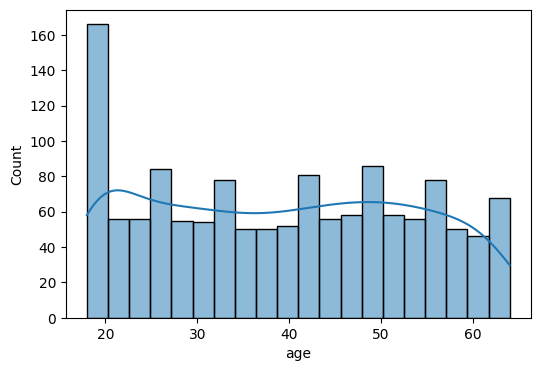

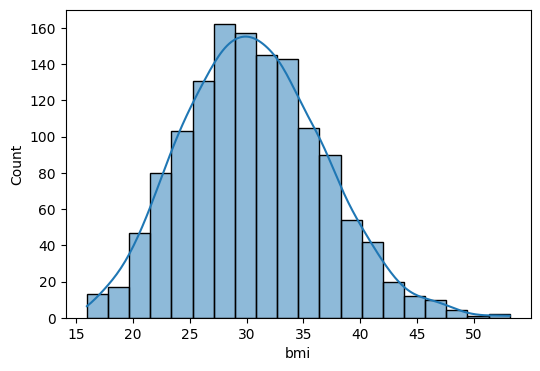

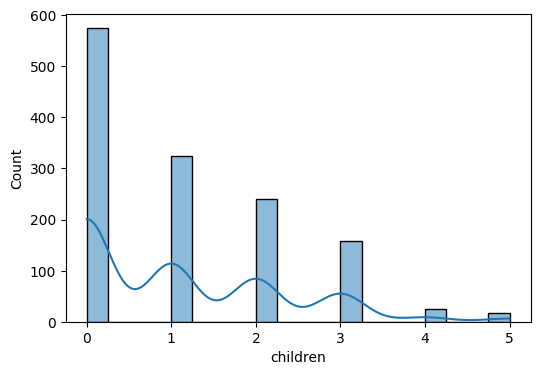

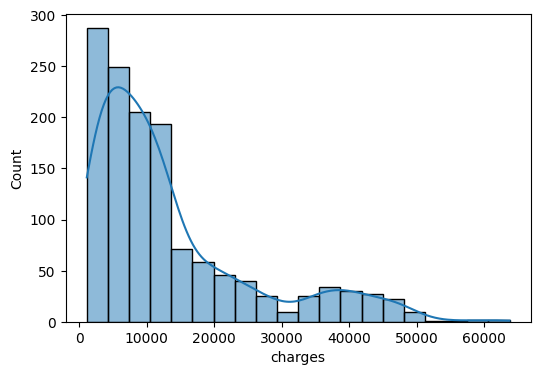

In [51]:
numeric_columns = ['age', 'bmi', 'children','charges']
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col] , kde = True , bins = 20)

In [52]:
df_cleaned = df.copy()
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [53]:
df.isna().head().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [54]:
df_cleaned.drop_duplicates(inplace =True)

In [55]:
df_cleaned.shape

(1337, 7)

In [56]:
df.shape

(1338, 7)

In [57]:
df_cleaned.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [58]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [59]:
df_cleaned.value_counts('sex')

,count
sex,
male,675
female,662


In [60]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':0 , 'female':1})

In [61]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [62]:
df_cleaned.value_counts('smoker')

,count
smoker,
no,1063
yes,274


In [63]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no': 0 , 'yes': 1})

In [64]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [65]:
df_cleaned.rename(columns = {
    'sex': 'is_Female',
    'smoker':'is_smoker'} , inplace = True )

In [66]:
df_cleaned

,age,is_Female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [67]:
df_cleaned.value_counts('region')

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [68]:
df_cleaned = pd.get_dummies(df_cleaned , columns = ['region'] , drop_first = True)

In [69]:
df_cleaned

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


In [70]:
df_cleaned['bmi category'] = pd.cut(
    df_cleaned['bmi'],
    bins = [0,18.5,24.9,29.9, float('inf')],
    labels=['underweight' , 'normal' , 'overweight' , 'obese']
)

In [71]:
df_cleaned

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category
0,19,1,27.900,0,1,16884.92400,False,False,True,overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,obese
2,28,0,33.000,3,0,4449.46200,False,True,False,obese
3,33,0,22.705,0,0,21984.47061,True,False,False,normal
4,32,0,28.880,0,0,3866.85520,True,False,False,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,obese
1334,18,1,31.920,0,0,2205.98080,False,False,False,obese
1335,18,1,36.850,0,0,1629.83350,False,True,False,obese
1336,21,1,25.800,0,0,2007.94500,False,False,True,overweight


In [72]:
df_cleaned = pd.get_dummies(df_cleaned , columns = ['bmi category'] , drop_first =  True)

In [73]:
df_cleaned.head()

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_normal,bmi category_overweight,bmi category_obese
0,19,1,27.900,0,1,16884.92400,False,False,True,False,True,False
1,18,0,33.770,1,0,1725.55230,False,True,False,False,False,True
2,28,0,33.000,3,0,4449.46200,False,True,False,False,False,True
3,33,0,22.705,0,0,21984.47061,True,False,False,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False,False,True,False


In [75]:
df_cleaned['is_smoker'] = df_cleaned['is_smoker'].fillna(0)
df_cleaned = df_cleaned.astype(int)

In [76]:
df_cleaned

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_normal,bmi category_overweight,bmi category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [77]:
df_cleaned.columns

Index(['age', 'is_Female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi category_normal', 'bmi category_overweight', 'bmi category_obese'],
      dtype='object')

In [78]:
from sklearn.preprocessing import StandardScaler
cols = ['age' , 'bmi' , 'children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [79]:
df_cleaned

,age,is_Female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_normal,bmi category_overweight,bmi category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0,1,0


In [80]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_Female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi category_normal', 'bmi category_overweight', 'bmi category_obese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi category_obese,0.197660
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_Female,-0.058046
8,bmi category_normal,-0.105656


In [81]:
cat_features = [
    'is_Female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi category_normal', 'bmi category_overweight', 'bmi category_obese'
]

In [82]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_Female,10.258784,0.01649,Reject Null (Keep Feature)
bmi category_obese,7.654464,0.05372,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi category_normal,4.263673,0.234364,Accept Null (Drop Feature)
bmi category_overweight,4.201575,0.240504,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [83]:
final_df = df_cleaned[['age', 'is_Female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi category_obese']]

In [84]:
final_df

,age,is_Female,bmi,children,is_smoker,charges,region_southeast,bmi category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0


In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

In [86]:
X = final_df.drop('charges' , axis =1)
y = final_df['charges']

In [87]:
X_train, X_test , y_train , y_test = train_test_split(X , y ,test_size = 0.20 , random_state = 42)

In [88]:
from sklearn.linear_model import LinearRegression

In [89]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [90]:
y_pred = model.predict(X_test)

In [91]:
y_pred

array([7.84431061e+03, 5.40212147e+03, 1.45803380e+04, 3.24260492e+04,
       8.94102201e+03, 1.32979787e+04, 3.01666893e+04, 1.40767199e+03,
       1.10977673e+04, 1.01111898e+04, 1.07566824e+04, 3.22059560e+04,
       3.14907449e+04, 1.63245464e+04, 1.02918275e+04, 8.58161724e+03,
       5.44235797e+03, 3.23876399e+04, 3.32088751e+03, 3.91384014e+03,
       4.63528957e+03, 2.88823240e+04, 1.38885119e+04, 2.96266960e+04,
       3.14645008e+04, 6.27171758e+03, 3.50039936e+04, 3.77918646e+04,
       1.23542875e+04, 1.42196090e+04, 7.46025419e+03, 1.30090259e+04,
       4.84668395e+02, 1.14090013e+04, 3.76722518e+04, 1.32876349e+04,
       3.78578301e+03, 4.45751963e+03, 3.13750054e+04, 8.02267282e+03,
       6.10133726e+03, 3.03262287e+04, 3.51986611e+04, 1.30249263e+04,
       7.89042648e+03, 3.00569068e+03, 5.21811622e+03, 7.70172638e+03,
       3.54276738e+03, 1.02703647e+04, 7.69443476e+03, 1.06031104e+04,
       3.03355262e+04, 4.59113064e+03, 1.16567118e+04, 1.12924348e+04,
      

In [92]:
y_test

,charges
900,8688
1064,5708
1256,11436
298,38746
237,4463
...,...
534,13831
542,13887
760,3925
1284,47403


In [94]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
r2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adjusted_r2

0.7986773111405272